In [1]:
import pandas as pd

red = pd.read_csv('winequality-red.csv', sep=';')
white = pd.read_csv('winequality-white.csv', sep=';')

red['wine_type'] = 0
white['wine_type'] = 1

df = pd.concat([red, white], axis=0, ignore_index=True)

In [2]:
print(df.shape)

(6497, 13)


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  wine_type             6497 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 660.0 KB


In [4]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378,0.753886
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255,0.430779
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000,0.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000,1.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000,1.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000,1.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000,1.000000


In [5]:
df['quality'].value_counts().sort_index()

quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64

array([[<Axes: title={'center': 'fixed acidity'}>,
        <Axes: title={'center': 'volatile acidity'}>,
        <Axes: title={'center': 'citric acid'}>,
        <Axes: title={'center': 'residual sugar'}>],
       [<Axes: title={'center': 'chlorides'}>,
        <Axes: title={'center': 'free sulfur dioxide'}>,
        <Axes: title={'center': 'total sulfur dioxide'}>,
        <Axes: title={'center': 'density'}>],
       [<Axes: title={'center': 'pH'}>,
        <Axes: title={'center': 'sulphates'}>,
        <Axes: title={'center': 'alcohol'}>,
        <Axes: title={'center': 'quality'}>],
       [<Axes: title={'center': 'wine_type'}>, <Axes: >, <Axes: >,
        <Axes: >]], dtype=object)

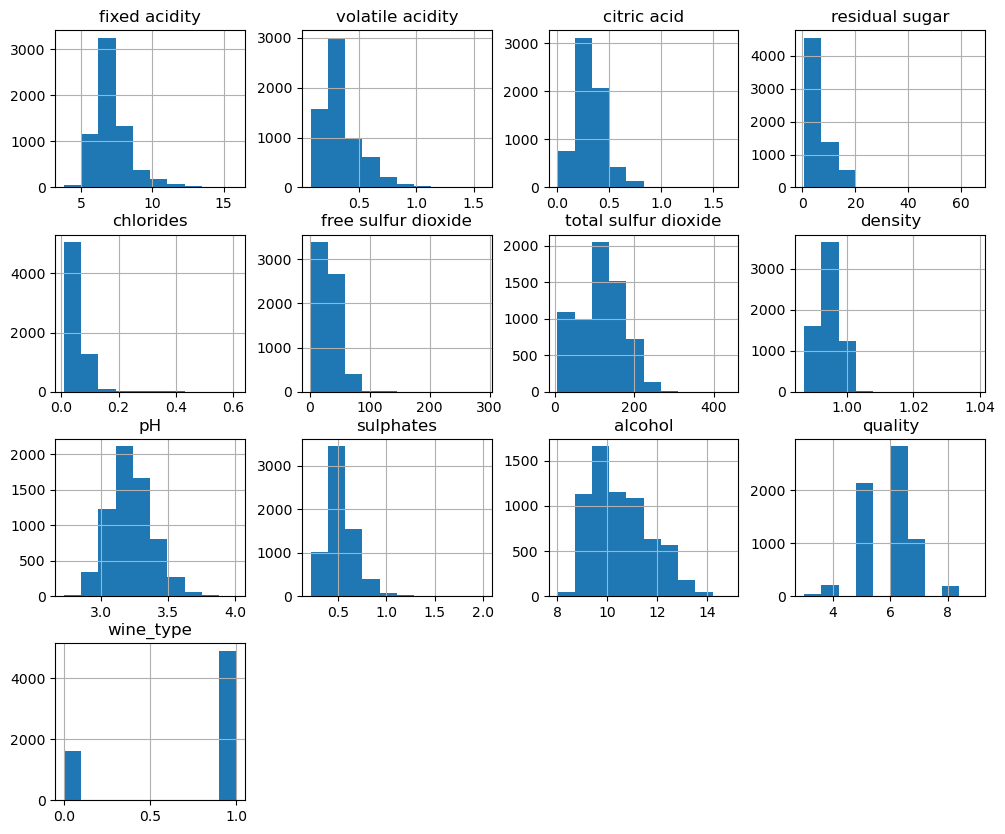

In [6]:
df.hist(figsize=(12,10))

In [7]:
df.corr()['quality'].sort_values(ascending=False)

quality                 1.000000
alcohol                 0.444319
wine_type               0.119323
citric acid             0.085532
free sulfur dioxide     0.055463
sulphates               0.038485
pH                      0.019506
residual sugar         -0.036980
total sulfur dioxide   -0.041385
fixed acidity          -0.076743
chlorides              -0.200666
volatile acidity       -0.265699
density                -0.305858
Name: quality, dtype: float64

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['quality'])
y = df['quality']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train.shape, X_test.shape)
print(X_train_scaled.mean(axis=0))

(5197, 12) (1300, 12)
[ 1.84574311e-16 -1.00490458e-16  1.26467583e-17  1.10402782e-16
  4.44345563e-16  4.92198162e-17  6.90444644e-17 -2.72787159e-14
 -1.72269357e-16  9.32442074e-16 -8.94159995e-16 -6.28919874e-17]


In [9]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2:", r2)

MAE: 0.5644129055666053
MSE: 0.5412384543695589
R2: 0.2671574851262719


In [11]:
import numpy as np
baseline_pred = np.full_like(y_test, y_train.mean(), dtype=float)
baseline_mae = mean_absolute_error(y_test, baseline_pred)
print("Baseline MAE:", baseline_mae)

Baseline MAE: 0.6690966681961484


In [12]:
import pandas as pd

results = pd.DataFrame({
    'actual': y_test,
    'predicted': y_pred
})
results['residual'] = results['actual'] - results['predicted']
results['abs_error'] = results['residual'].abs()

grouped = results.groupby('actual')['abs_error'].mean()
print(grouped)

actual
3    2.612539
4    1.439360
5    0.532765
6    0.354360
7    0.792980
8    1.599982
9    2.354554
Name: abs_error, dtype: float64


In [13]:
grouped_signed = results.groupby('actual')['residual'].mean()
print(grouped_signed)

actual
3   -2.612539
4   -1.439360
5   -0.505978
6    0.137242
7    0.791797
8    1.599982
9    2.354554
Name: residual, dtype: float64


In [14]:
coefficients = pd.Series(model.coef_, index=X.columns).sort_values(ascending=False)
print(coefficients)

residual sugar          0.301300
alcohol                 0.277079
fixed acidity           0.118681
sulphates               0.113420
free sulfur dioxide     0.104242
pH                      0.084217
citric acid            -0.014161
chlorides              -0.020291
total sulfur dioxide   -0.091639
wine_type              -0.143580
volatile acidity       -0.244675
density                -0.307099
dtype: float64


In [15]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


In [16]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X_train_scaled, i) for i in range(X_train_scaled.shape[1])]
print(vif_data)

                 feature        VIF
0          fixed acidity   4.842477
1       volatile acidity   2.167735
2            citric acid   1.629120
3         residual sugar   9.504676
4              chlorides   1.672394
5    free sulfur dioxide   2.276665
6   total sulfur dioxide   4.141576
7                density  21.441550
8                     pH   2.488545
9              sulphates   1.560278
10               alcohol   5.341378
11             wine_type   7.266424


In [17]:
df['quality_binary'] = (df['quality'] >= 7).astype(int)

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['quality', 'quality_binary'])
y = df['quality_binary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train.shape, X_test.shape)
print(X_train_scaled.mean(axis=0))

(5197, 12) (1300, 12)
[ 1.84574311e-16 -1.00490458e-16  1.26467583e-17  1.10402782e-16
  4.44345563e-16  4.92198162e-17  6.90444644e-17 -2.72787159e-14
 -1.72269357e-16  9.32442074e-16 -8.94159995e-16 -6.28919874e-17]


In [19]:
from sklearn.linear_model import LogisticRegression

model_log = LogisticRegression(class_weight='balanced')
model_log.fit(X_train_scaled, y_train)
y_pred_log = model_log.predict(X_test_scaled)
y_pred_proba_log = model_log.predict_proba(X_test_scaled)[:, 1]

In [20]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, classification_report

cm = confusion_matrix(y_test, y_pred_log)
print(cm)

[[730 318]
 [ 61 191]]


In [21]:
precision = precision_score(y_test, y_pred_log)
recall = recall_score(y_test, y_pred_log)
f1 = f1_score(y_test, y_pred_log)
print(precision, recall, f1)

0.37524557956778 0.7579365079365079 0.5019710906701709


In [22]:
roc_auc = roc_auc_score(y_test, y_pred_proba_log)
print(roc_auc)

0.8121137768084333


In [25]:
from sklearn.tree import DecisionTreeClassifier

model_tree = DecisionTreeClassifier(class_weight='balanced', random_state=42)
model_tree.fit(X_train, y_train)
y_pred_tree = model_tree.predict(X_test)
y_pred_proba_tree = model_tree.predict_proba(X_test) [:, 1]

In [26]:
cm_tree = confusion_matrix(y_test, y_pred_tree)
print(cm_tree)

[[956  92]
 [ 90 162]]


In [28]:
precision_tree = precision_score(y_test, y_pred_tree)
recall_tree = recall_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)
print(precision_tree, recall_tree, f1_tree)

roc_auc_tree = roc_auc_score(y_test, y_pred_proba_tree)
print(roc_auc_tree)

0.6377952755905512 0.6428571428571429 0.6403162055335968
0.777535441657579


In [29]:
y_pred_tree_train = model_tree.predict(X_train)
train_f1 = f1_score(y_train, y_pred_tree_train)
print("Train F1:", train_f1)
print("Test F1:", f1_tree)

Train F1: 1.0
Test F1: 0.6403162055335968


In [30]:
from sklearn.model_selection import cross_val_score
import numpy as np

depths = range(1, 21)
cv_scores = []

for d in depths:
    tree = DecisionTreeClassifier(max_depth=d, class_weight='balanced', random_state=42)
    scores = cross_val_score(tree, X_train, y_train, cv=5, scoring='f1')
    cv_scores.append(scores.mean())

for d, s in zip(depths, cv_scores):
    print(d, s)

1 0.4984505618893914
2 0.4898362440835366
3 0.5247904449418045
4 0.5145029478961741
5 0.5187109943374835
6 0.5223231834852782
7 0.5344016091391033
8 0.547157199975429
9 0.5586742325812061
10 0.5670383453306879
11 0.5695230530627008
12 0.57377858190739
13 0.5753061555471259
14 0.5744955199397896
15 0.5755727741671474
16 0.576574577276368
17 0.5752479003080714
18 0.5728509807377787
19 0.5765880724204384
20 0.5777917142137705


In [31]:
model_tree_final = DecisionTreeClassifier(max_depth=12, class_weight='balanced', random_state=42)
model_tree_final.fit(X_train, y_train)

y_pred_tree_final = model_tree_final.predict(X_test)
y_pred_proba_tree_final = model_tree_final.predict_proba(X_test)[:, 1]

# Train F1 to check overfitting gap
y_pred_tree_final_train = model_tree_final.predict(X_train)
train_f1_final = f1_score(y_train, y_pred_tree_final_train)

print("Train F1:", train_f1_final)
print("Test F1:", f1_score(y_test, y_pred_tree_final))
print("Test Precision:", precision_score(y_test, y_pred_tree_final))
print("Test Recall:", recall_score(y_test, y_pred_tree_final))
print("Test ROC-AUC:", roc_auc_score(y_test, y_pred_proba_tree_final))

Train F1: 0.7877614252517429
Test F1: 0.5930599369085173
Test Precision: 0.49214659685863876
Test Recall: 0.746031746031746
Test ROC-AUC: 0.796948836786623


In [32]:
importances = pd.Series(model_tree_final.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(importances)

alcohol                 0.318331
volatile acidity        0.120021
sulphates               0.073740
free sulfur dioxide     0.072515
citric acid             0.070299
residual sugar          0.064108
density                 0.061113
chlorides               0.060037
pH                      0.056383
fixed acidity           0.054911
total sulfur dioxide    0.046287
wine_type               0.002255
dtype: float64


In [33]:
regression_comparison = pd.DataFrame({
    'Model': ['Baseline (predict mean)', 'Linear Regression'],
    'MAE': [0.669, 0.564],
    'MSE': [None, 0.541],
    'R2': [0.0, 0.267],
    'Notes': [
        'Naive reference point',
        '15.7% MAE improvement over baseline; regression-to-mean on extremes'
    ]
})
print(regression_comparison)

                     Model    MAE    MSE     R2  \
0  Baseline (predict mean)  0.669    NaN  0.000   
1        Linear Regression  0.564  0.541  0.267   

                                               Notes  
0                              Naive reference point  
1  15.7% MAE improvement over baseline; regressio...  


In [34]:
classification_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree (unlimited)', 'Decision Tree (depth=12, tuned)'],
    'Train F1': [None, 1.000, 0.788],
    'Test F1': [0.502, 0.640, 0.593],
    'Precision': [0.375, 0.638, 0.492],
    'Recall': [0.758, 0.643, 0.746],
    'ROC-AUC': [0.812, 0.778, 0.797],
    'Notes': [
        "class_weight='balanced'; high recall, low precision",
        'Severely overfit — perfect train score, large train/test gap',
        'More reliable despite slightly lower test F1 — smaller overfitting gap'
    ]
})
print(classification_comparison)

                             Model  Train F1  Test F1  Precision  Recall  \
0              Logistic Regression       NaN    0.502      0.375   0.758   
1        Decision Tree (unlimited)     1.000    0.640      0.638   0.643   
2  Decision Tree (depth=12, tuned)     0.788    0.593      0.492   0.746   

   ROC-AUC                                              Notes  
0    0.812  class_weight='balanced'; high recall, low prec...  
1    0.778  Severely overfit — perfect train score, large ...  
2    0.797  More reliable despite slightly lower test F1 —...  


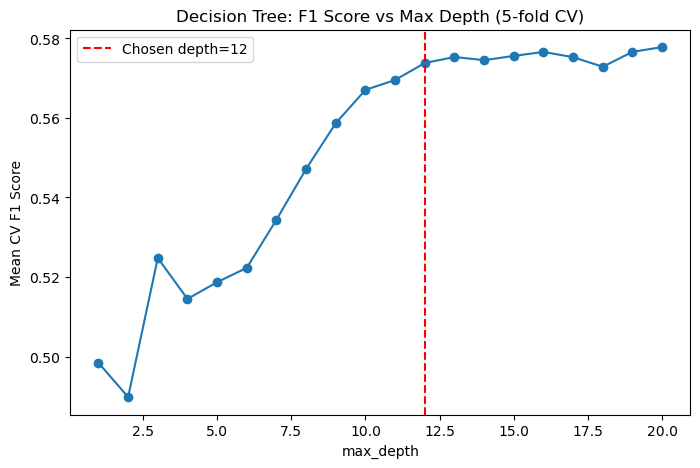

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(depths, cv_scores, marker='o')
plt.xlabel('max_depth')
plt.ylabel('Mean CV F1 Score')
plt.title('Decision Tree: F1 Score vs Max Depth (5-fold CV)')
plt.axvline(x=12, color='red', linestyle='--', label='Chosen depth=12')
plt.legend()
plt.savefig('images/cv_depth_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

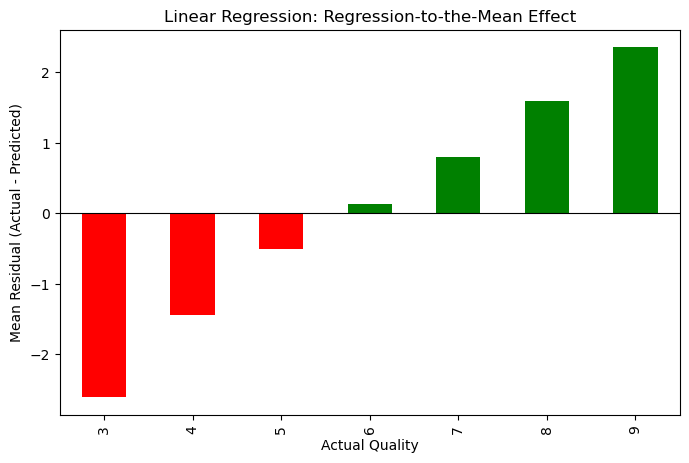

In [36]:
plt.figure(figsize=(8,5))
grouped_signed.plot(kind='bar', color=['red' if v < 0 else 'green' for v in grouped_signed])
plt.axhline(y=0, color='black', linewidth=0.8)
plt.xlabel('Actual Quality')
plt.ylabel('Mean Residual (Actual - Predicted)')
plt.title('Linear Regression: Regression-to-the-Mean Effect')
plt.savefig('images/regression_to_mean.png', dpi=150, bbox_inches='tight')
plt.show()

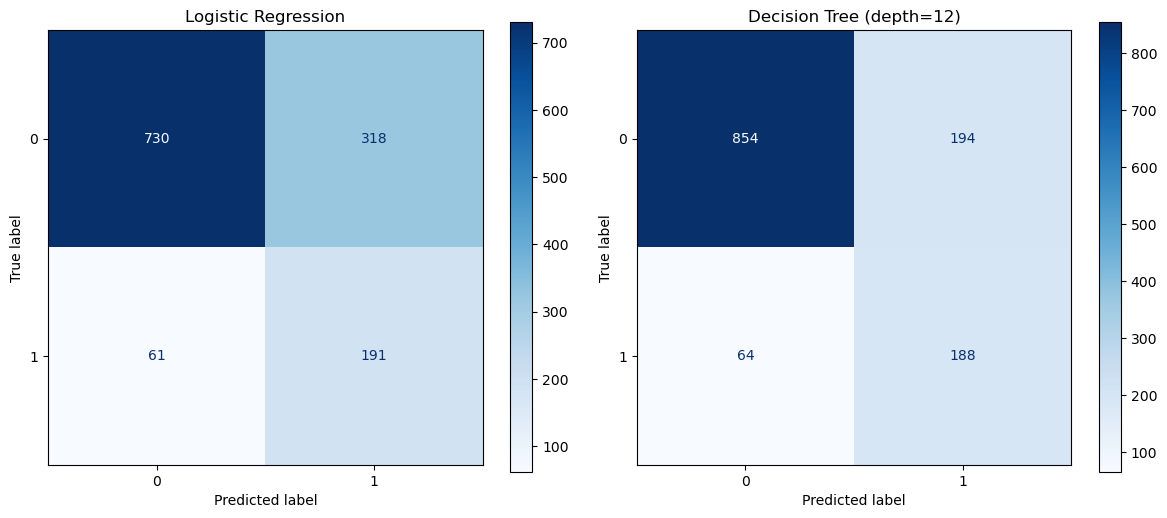

In [37]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_log, ax=axes[0], cmap='Blues')
axes[0].set_title('Logistic Regression')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tree_final, ax=axes[1], cmap='Blues')
axes[1].set_title('Decision Tree (depth=12)')

plt.tight_layout()
plt.savefig('images/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

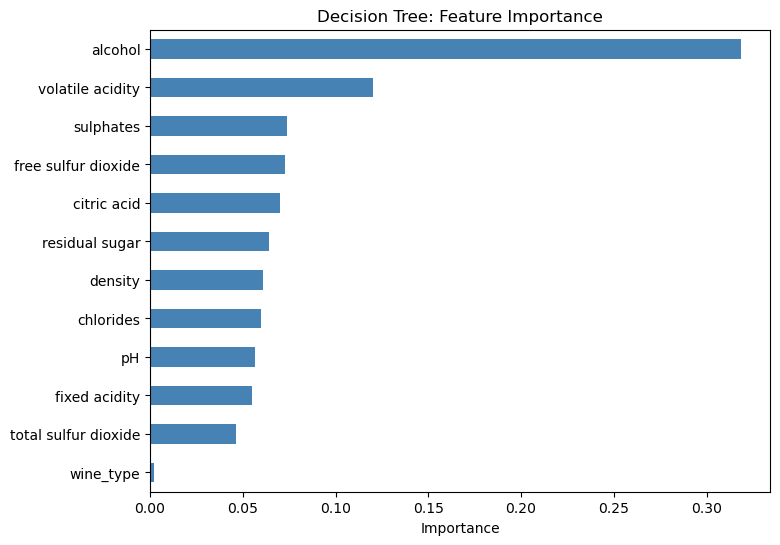

In [38]:
plt.figure(figsize=(8,6))
importances.sort_values().plot(kind='barh', color='steelblue')
plt.xlabel('Importance')
plt.title('Decision Tree: Feature Importance')
plt.savefig('images/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()